## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

#Part 2 (Homework Assignment), 100 points

It was unclear whether I should just write these answers in the notebook or write them separately in a PDF, so I have done both.

1: Central to our research is the concept of urgency. Urgency is in many ways an inherently multimodal concept, for example multimodal fusion is often needed to determine whether a situation is urgent because whether a question is urgent can depend on the context it is asked in. However, there are still fundamental unimodal aspects to the concept of urgency.

For example, a query about nearby cars paired with a video of fast traffic should be encoded closer to other urgent situations than to a menu-reading query paired with a video of a restaurant.

This is especially important given that the videos are often off-centered and have high motion blur, so it is important to encode what is actually happening in the video before any reasoning is done about prompt urgency.

Thus, contrastive alignment is a good method to ensure that both encoders have a similar baseline understanding of what situations might be similar or dissimilar in urgency.
As such, we should do intermediate fusion, where encoding occurs separately to start, but cross-attention is allowed before making the ultimate decision on whether a query is urgent or not.

2: The most natural experiment here is an ablation study similar to what ALBEF does in Table 1 of their paper. We would train several variants and compare them against each other:

First, unimodal baselines (text-only and video-only) to establish a performance floor. Then, fusion without alignment, where we skip the contrastive step and go straight to cross-attention fusion on raw encoder outputs. Then, fusion with alignment, where we add contrastive alignment before fusion. Finally, we would hold alignment constant and vary the fusion type (early, late, intermediate) to see which works best.

We would evaluate each variant on the same held-out test set, and critically, we would break results down by urgent vs non-urgent queries separately. The whole idea of our project is that different query types benefit from different computational treatment, so reporting only aggregate accuracy would be insufficient. We would also compare latency across fusion types, since for urgent queries speed matters just as much as accuracy. Late fusion should be the fastest and intermediate fusion the slowest, and we want to quantify whether that tradeoff is worth it.

There are several challenges we foresee. Our dataset is small (around 5000 questions and 1300 videos), which makes contrastive alignment harder because it relies on large batches of negative pairs to be effective. ALBEF uses queues of 65,536 negatives, which is not feasible at our scale. The visual data is also extremely noisy due to blur, camera shake, and off-center framing from visually impaired users, so the visual encoder may produce weak features that are difficult to align with text regardless of method. We also face a temporal misalignment problem that standard image-text alignment does not address. Users often ask about past events ("What was that?"), so aligning the query to the correct video frames requires temporal reasoning on top of the usual cross-modal alignment. Finally, class imbalance is a concern, since the vast majority of queries are non-urgent, meaning our evaluations on urgent queries will have small sample sizes and potentially high variance.

3: The Platonic representation hypothesis suggests that as models scale up, their representations naturally converge toward a shared statistical model of reality, because all modalities are ultimately projections of the same underlying world events. For our task, this would mean that the real-world events that produce urgency (a car approaching or a busy intersection) would eventually be represented similarly regardless of whether they are observed through video or described in text, simply as a consequence of scale.

I believe that some level of alignment would emerge from scaling alone, as many situations are obviously urgent across multiple modalities. However, I do not think we would reach sufficient alignment for our task without explicit contrastive training. The paper's mathematical argument for convergence relies on observations being bijective, meaning each modality preserves all the information about the underlying event. Our data violates this assumption severely. A blurry, shaking egocentric video of a car approaching loses far more information than a clear text description like "a car is coming from the left." The two modalities are not capturing reality with equal fidelity, so the theoretical conditions for automatic convergence do not hold. On top of this, even under ideal conditions the paper's own experiments show alignment scores reaching only about 0.16 out of 1.0, so convergence is far from complete even in the best case. With noisy, domain-specific data like ours, we would expect even less automatic alignment and would need to enforce it explicitly.

4: A strong argument against the Platonic representation hypothesis is that different modalities have fundamentally different expressive powers. There are some aspects of reality that can only be captured in certain modalities and not in others. As such, there are certain concepts which may have a rich representation in one modality but not in another. For example, the paper itself notes that an image would struggle to convey a concept like "I believe in the freedom of speech," while language would struggle to capture the full experience of watching a total solar eclipse (which I can personally attest to; words still fail me when I try to describe the experience of totality to my family who didn't see the eclipse). The mathematical argument for convergence requires bijective observations, meaning each modality fully preserves all information about the underlying event, and these examples show that this assumption does not hold in practice.

More relevant to our project is the fact that the platonic ideal of an urgent situation, i.e. one in which alarm and rapid action is required, is subtly disjoint from the platonic ideal of an urgent question, i.e. a question which demands an immediate answer. Questions which may appear urgent can be non-urgent if the situation is calm and safe, while seemingly innocuous queries such as "What is 10 meters ahead of me?" can be very urgent if the scene in question involves a car moving towards the camera.

5: We would propose several experiments to validate whether alignment emerges in our task.
First, we would directly measure alignment using the mutual nearest-neighbor metric from the Platonic Representation paper. For each paired video-question sample in our dataset, we would find its *k* nearest neighbors in the video encoder's space and in the text encoder's space, and measure how much those neighbor sets overlap. Higher overlap means the two encoders agree on which data points are similar to each other, and are thus aligned.

Second, we would track this metric at checkpoints throughout training rather than just at the end. If alignment emerges naturally as a byproduct of learning, we should see the score climbing even before any explicit contrastive loss is introduced. If the score stays flat until we add contrastive training, that would be evidence that alignment needs to be forced for our data rather than emerging on its own.

Third, we would compare pretrained foundation models at different scales, following the methodology of the Platonic representation paper. We would take several models of increasing size and measure their cross-modal alignment on EgoBlind data without any finetuning. If larger models show higher alignment out of the box, that supports the hypothesis that alignment emerges from scale. If alignment stays low regardless of model size, it would suggest that our data is different enough from typical pretraining distributions that alignment does not transfer automatically.

Finally, we would split our test set by urgent vs non-urgent queries and measure alignment separately for each category. It is plausible that alignment emerges more easily for one category than the other. For instance, urgent situations like oncoming traffic might be described more consistently across modalities than non-urgent ones like reading a menu, which would show up as higher alignment scores for the urgent subset (perhaps Tolstoy would say all urgent situations are urgent in the same way). This would directly inform how much explicit alignment work is needed for each branch of our routing architecture.

6: The main risk of strong or perfect alignment is loss of modality-specific information. If you force video and text representations into a perfectly shared space, the encoders are pressured to retain only information that is common to both modalities and discard anything unique to one. For our project, this is a real concern. Video carries information that text simply cannot, such as motion speed, spatial layout, and depth cues. Text carries information that video cannot, such as abstract intent behind the question and linguistic cues about urgency like the difference between the brevity of "Car?" and the calmness of "Can you describe what is on the menu in front of me?" Perfect alignment would encourage the encoders to throw away exactly these modality-specific signals, which are some of the most useful features for our task.

Another risk is that perfect alignment would collapse cases where the two modalities disagree. For our system, disagreement between modalities is actually one of the most important signals. A calm, casually worded question paired with a video showing a dangerous scene is exactly the kind of situation our model needs to flag as urgent. But if both modalities are forced into the same representation, that tension gets smoothed over and the model loses its ability to detect the mismatch.

To validate that these risks are not present, we would design several experiments. First, we would train a linear probe on the aligned video representations to predict modality-specific features like optical flow magnitude, and separately train a probe on the aligned text representations to predict text-specific features like question length and word choice patterns. If these probes fail, it means the alignment process has destroyed useful modality-specific information. Second, we would construct a test set of deliberately mismatched pairs, where the text sounds non-urgent but the video shows a dangerous scene and vice versa, and measure whether our model can still correctly classify urgency. If a strongly aligned model performs worse on these mismatched cases than a less aligned one, that would confirm that over-alignment is collapsing a signal we need to preserve.

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [ ]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [ ]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_B.T

# Transpose
mat_A_transpose = mat_A.T

# Matrix multiplication
mat_mult  = mat_A @ mat_B

# Element-wise multiplication
mat_mult_elm = mat_A * mat_B.T

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [ ]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.2571, 0.6167, 0.6440],
        [0.3587, 0.6954, 0.8236],
        [0.5275, 0.8993, 1.1551]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [ ]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A
diag = torch.diagonal(A) # I think it is impossible with einsum because A is not square

# Outer Product of A and B
outer = torch.einsum('ij,kl->ijkl', A, B)

In [ ]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    assert to_list(ans) == expected

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

fatal: destination path 'MultiBench' already exists and is not an empty directory.
/content/MultiBench


# Getting AV-MNIST dataset

In [ ]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

mkdir: cannot create directory ‘data’: File exists


In [ ]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
From (redirected): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp&confirm=t&uuid=148098d3-9376-40fe-ae13-aa892c4c4b3c
To: /content/MultiBench/avmnist.tar.gz
100% 1.60G/1.60G [00:14<00:00, 111MB/s]
avmnist/
avmnist/test_labels.npy
avmnist/image/
avmnist/image/train_data.npy
avmnist/image/test_data.npy
avmnist/audio/
avmnist/audio/train_data.npy
avmnist/audio/test_data.npy
avmnist/train_labels.npy
avmnist/avmnist_temp/
avmnist/avmnist_temp/train_labels.npy
avmnist/avmnist_temp/image/
avmnist/avmnist_temp/image/test_data.npy
avmnist/avmnist_temp/image/train_data.npy
avmnist/avmnist_temp/test_labels.npy


In [ ]:
# 1. Path to the folder you untarred
data_dir = '/content/MultiBench/avmnist'

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Getting packages

In [ ]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [ ]:
class AudioModel(nn.Module):
    def __init__(self):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [ ]:
class ImageModel(nn.Module):
    def __init__(self):
        super(ImageModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

# Training and Testing

We use cross-entropy due to this being a classification task

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

# Audio:

In [ ]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1, epochs = 15, lr=1e-3)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7debbcd9f560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
Exception ignored in: Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7debbcd9f560><function _MultiProcessingDataLoaderIter.__del__ at 0x7debbcd9f560>
    
Traceback (most recent call last):
if w.is_alive():Traceback (most recent call last):
Exception ignored in: 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
     <function _MultiProcessingDataLoaderIter.__del__ at 0x7debbcd9f560> 
 self._shutdown_workers()     Traceback (most recent call

Epoch 0: Train Loss: 2.1232 | Valid Acc: 39.02%
Epoch 1: Train Loss: 2.0295 | Valid Acc: 40.60%
Epoch 2: Train Loss: 2.0094 | Valid Acc: 40.68%
Epoch 3: Train Loss: 1.9949 | Valid Acc: 41.40%
Epoch 4: Train Loss: 1.9872 | Valid Acc: 41.86%
Epoch 5: Train Loss: 1.9804 | Valid Acc: 41.94%
Epoch 6: Train Loss: 1.9732 | Valid Acc: 41.84%
Epoch 7: Train Loss: 1.9710 | Valid Acc: 41.94%
Epoch 8: Train Loss: 1.9659 | Valid Acc: 41.92%
Epoch 9: Train Loss: 1.9637 | Valid Acc: 42.20%
Epoch 10: Train Loss: 1.9622 | Valid Acc: 42.20%
Epoch 11: Train Loss: 1.9584 | Valid Acc: 42.12%
Epoch 12: Train Loss: 1.9581 | Valid Acc: 42.22%
Epoch 13: Train Loss: 1.9563 | Valid Acc: 42.12%
Epoch 14: Train Loss: 1.9527 | Valid Acc: 42.04%

--- Final Evaluation Complete ---
Final Test Loss: 1.9962 | Test Accuracy: 41.31%


# Image:

In [ ]:
import torch.nn.functional as F
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0, epochs = 15, lr=1e-3)

Epoch 0: Train Loss: 1.0174 | Valid Acc: 67.26%
Epoch 1: Train Loss: 0.9339 | Valid Acc: 68.28%
Epoch 2: Train Loss: 0.9185 | Valid Acc: 67.90%
Epoch 3: Train Loss: 0.9135 | Valid Acc: 69.10%
Epoch 4: Train Loss: 0.9089 | Valid Acc: 68.60%
Epoch 5: Train Loss: 0.9033 | Valid Acc: 67.76%
Epoch 6: Train Loss: 0.8999 | Valid Acc: 68.52%
Epoch 7: Train Loss: 0.9000 | Valid Acc: 69.32%
Epoch 8: Train Loss: 0.8960 | Valid Acc: 68.62%
Epoch 9: Train Loss: 0.8967 | Valid Acc: 68.82%
Epoch 10: Train Loss: 0.8930 | Valid Acc: 69.34%
Epoch 11: Train Loss: 0.8938 | Valid Acc: 69.02%
Epoch 12: Train Loss: 0.8896 | Valid Acc: 68.32%
Epoch 13: Train Loss: 0.8882 | Valid Acc: 68.40%
Epoch 14: Train Loss: 0.8880 | Valid Acc: 67.74%

--- Final Evaluation Complete ---
Final Test Loss: 0.8887 | Test Accuracy: 64.62%


Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

1: Best audio: ~42%, 15 epochs, BatchNorm, 32/64 filters, lr=1e-3. Best image: ~65%, 15 epochs, BatchNorm, 32/64 filters, dropout 0.3, lr=5e-4.

I tried so many different hyperparameters, with and without my modifications. Nothing improved meaningfully beyond the baseline despite me trying more epochs, learning rate changes, and architectural modifications. I am so lost as to how to improve any more.

2: Image significantly outperforms audio, which suggests the visual shape of digits is a much stronger signal than the noisy spectrograms. To improve audio, we would likely need a fundamentally different approach like a pretrained audio encoder rather than raw spectrograms.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = encoders = [ImageEncoder(output_dim=64).cuda(), AudioEncoder(output_dim=64).cuda()]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat().cuda()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = MLP(128, 256, 10).cuda()

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...
Epoch 0 train loss: tensor(0.8929, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7493, device='cuda:0') acc: 0.7202
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(0.7640, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7261, device='cuda:0') acc: 0.7326
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 2 train loss: tensor(0.7128, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(0.7287, device='cuda:0') acc: 0.7266


...

Epoch 3 train loss: tensor(0.6824, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7315, device='cuda:0') acc: 0.7348
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4 train loss: tensor(0.6528, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7407, device='cuda:0') acc: 0.7268
Training Time: 63.38327646255493
Training Peak Mem: 8957.72265625
Training Params: 1077258


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


acc: 0.7024
Inference Time: 2.994443893432617
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

1: The model getting stuck in a loss range suggests it's hit a local minimum or a plateau. Ways to fix it include lowering the learning rate or adding BatchNorm to stabilize gradients.

2: Other fusion methods I've seen include tensor fusion (outer product of representations), and multiplicative interactions (element-wise product outer product of representations). These could lead to improvements over simple concatenation because they capture interaction effects between modalities rather than just stacking features side by side.

3: Early fusion combines raw inputs before any encoding, so a single network processes everything jointly. The benefit is that the model can learn low-level cross-modal interactions from the start, but the tradeoff is that it has to learn everything at once (alignment, unimodal understanding, and cross-modal reasoning), which is harder to optimize and often performs worse. Late fusion encodes each modality fully independently, then combines at the end. The benefit is that each encoder can specialize on its own modality, and it's faster since encoders can run in parallel. The tradeoff is that it can only capture high-level interactions and misses fine-grained cross-modal patterns.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

I'm only using the first split of my train and test data because otherwise this would take forever. Answers are below, after data.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Imports incase you need them again! Feel free to include anything else you need
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import cv2
import os
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

BASE_DIR = "/content/drive/MyDrive/MMAI_Project"
TRAIN_CSV = os.path.join(BASE_DIR, "train_labeled.csv")
TEST_CSV = os.path.join(BASE_DIR, "test_labeled.csv")
TRAIN_VIDEO_DIR = os.path.join(BASE_DIR, "train_videos")
TEST_VIDEO_DIR = os.path.join(BASE_DIR, "test_videos")

Mounted at /content/drive


In [10]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df = train_df[train_df["urgency"].isin(["urgent", "not_urgent"])].reset_index(drop=True)
test_df = test_df[test_df["urgency"].isin(["urgent", "not_urgent"])].reset_index(drop=True)

train_df["label"] = (train_df["urgency"] == "urgent").astype(int)
test_df["label"] = (test_df["urgency"] == "urgent").astype(int)

# Filter to only rows where we have the video on disk
train_df["vname_fmt"] = train_df["video_name"].apply(lambda x: f"{int(x):05d}")
test_df["vname_fmt"] = test_df["video_name"].apply(lambda x: f"{int(x):05d}")

train_available = set(f.replace(".mp4", "") for f in os.listdir(TRAIN_VIDEO_DIR) if f.endswith(".mp4"))
test_available = set(f.replace(".mp4", "") for f in os.listdir(TEST_VIDEO_DIR) if f.endswith(".mp4"))

train_df = train_df[train_df["vname_fmt"].isin(train_available)].reset_index(drop=True)
test_df = test_df[test_df["vname_fmt"].isin(test_available)].reset_index(drop=True)

print(f"Train videos on disk: {len(train_available)}")
print(f"Test videos on disk: {len(test_available)}")
print(f"Train rows with available videos: {len(train_df)}")
print(f"Test rows with available videos: {len(test_df)}")
print(f"\nTrain urgency split:\n{train_df['urgency'].value_counts()}")
print(f"\nTest urgency split:\n{test_df['urgency'].value_counts()}")

Train videos on disk: 43
Test videos on disk: 93
Train rows with available videos: 191
Test rows with available videos: 399

Train urgency split:
urgency
urgent        133
not_urgent     58
Name: count, dtype: int64

Test urgency split:
urgency
urgent        250
not_urgent    149
Name: count, dtype: int64


In [11]:
tfidf = TfidfVectorizer(max_features=128, stop_words="english")
X_text_train = tfidf.fit_transform(train_df["question"].astype(str)).toarray()
X_text_test = tfidf.transform(test_df["question"].astype(str)).toarray()
print(f"Text features: train {X_text_train.shape}, test {X_text_test.shape}")

Text features: train (191, 128), test (399, 128)


In [12]:
def extract_video_features(video_path, start_time=0.0):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    cap.set(cv2.CAP_PROP_POS_MSEC, start_time * 1000)
    ret, frame = cap.read()
    if not ret:
        cap.set(cv2.CAP_PROP_POS_MSEC, 0)
        ret, frame = cap.read()
    if not ret:
        cap.release()
        return None

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    ret2, frame2 = cap.read()
    flow_mag = 0.0
    if ret2:
        gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
        flow = cv2.calcOpticalFlowFarneback(gray, gray2, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        flow_mag = mag.mean()

    cap.release()
    return [
        gray.mean(), gray.std(),
        hsv[:,:,0].mean(), hsv[:,:,1].mean(), hsv[:,:,2].mean(),
        cv2.Laplacian(gray, cv2.CV_64F).var(),
        cv2.Canny(gray, 100, 200).mean() / 255.0,
        flow_mag
    ]

def extract_all_features(df, video_dir):
    features = {}
    total = len(df)
    for i, row in df.iterrows():
        vpath = os.path.join(video_dir, row["vname_fmt"] + ".mp4")
        start = float(row.get("start-time/s", 0) or 0)
        feats = extract_video_features(vpath, start)
        if feats is not None:
            features[i] = feats
        if (len(features)) % 25 == 0:
            print(f"  {len(features)}/{total} samples extracted...")
    print(f"  Done: {len(features)}/{total} samples")
    return features

print("Extracting train video features...")
train_vid_feats = extract_all_features(train_df, TRAIN_VIDEO_DIR)
print("\nExtracting test video features...")
test_vid_feats = extract_all_features(test_df, TEST_VIDEO_DIR)

Extracting train video features...
  25/191 samples extracted...
  50/191 samples extracted...
  75/191 samples extracted...
  100/191 samples extracted...
  125/191 samples extracted...
  150/191 samples extracted...
  175/191 samples extracted...
  Done: 191/191 samples

Extracting test video features...
  25/399 samples extracted...
  50/399 samples extracted...
  75/399 samples extracted...
  100/399 samples extracted...
  125/399 samples extracted...
  150/399 samples extracted...
  175/399 samples extracted...
  200/399 samples extracted...
  225/399 samples extracted...
  250/399 samples extracted...
  275/399 samples extracted...
  300/399 samples extracted...
  325/399 samples extracted...
  350/399 samples extracted...
  375/399 samples extracted...
  Done: 399/399 samples


In [13]:
train_idx = sorted(train_vid_feats.keys())
test_idx = sorted(test_vid_feats.keys())

X_text_train_f = X_text_train[train_idx]
X_vid_train_f = np.array([train_vid_feats[i] for i in train_idx])
y_train_f = train_df["label"].values[train_idx]

X_text_test_f = X_text_test[test_idx]
X_vid_test_f = np.array([test_vid_feats[i] for i in test_idx])
y_test_f = test_df["label"].values[test_idx]

vid_scaler = StandardScaler()
X_vid_train_f = vid_scaler.fit_transform(X_vid_train_f)
X_vid_test_f = vid_scaler.transform(X_vid_test_f)

print(f"Train samples: {len(train_idx)}, Test samples: {len(test_idx)}")
print(f"Text dim: {X_text_train_f.shape[1]}, Video dim: {X_vid_train_f.shape[1]}")
print(f"Train label split: {np.bincount(y_train_f)}")
print(f"Test label split: {np.bincount(y_test_f)}")

Train samples: 191, Test samples: 399
Text dim: 128, Video dim: 8
Train label split: [ 58 133]
Test label split: [149 250]


In [14]:
class EgoBlindDataset(Dataset):
    def __init__(self, text_feats, vid_feats, labels):
        self.text = torch.tensor(text_feats, dtype=torch.float32)
        self.vid = torch.tensor(vid_feats, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.text[idx], self.vid[idx], self.labels[idx]

train_dataset = EgoBlindDataset(X_text_train_f, X_vid_train_f, y_train_f)
test_dataset = EgoBlindDataset(X_text_test_f, X_vid_test_f, y_test_f)

val_size = int(0.15 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_sub, val_sub = random_split(train_dataset, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_sub, batch_size=64, shuffle=True)
val_loader = DataLoader(val_sub, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

TEXT_DIM = X_text_train_f.shape[1]
VID_DIM = X_vid_train_f.shape[1]
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 3, Val batches: 1, Test batches: 7


In [15]:
class TextEncoder(nn.Module):
    def __init__(self, input_dim, output_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    def forward(self, x):
        return self.net(x)

class VideoEncoder(nn.Module):
    def __init__(self, input_dim, output_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# Early Fusion

In [16]:
class EarlyFusion(nn.Module):
  def __init__(self):
    super(EarlyFusion, self).__init__()

  def forward(self, x):
    return torch.einsum('bi,bj->bij', x[0], x[1])

# (5 Points) Late Fusion

In [17]:
class LateFusion(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return torch.cat(x, dim=-1)

# (5 points) Tensor Fusion

In [18]:
class TensorFusion(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    batch_size = x[0].size(0)
    ones = torch.ones(batch_size, 1, device=x[0].device)
    x0 = torch.cat([x[0], ones], dim=1)
    x1 = torch.cat([x[1], ones], dim=1)
    fused = torch.einsum('bi,bj->bij', x0, x1)
    return fused.view(batch_size, -1)

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [23]:
class LMFFusion(nn.Module):
  def __init__(self, dim_x1, dim_x2, output_dim, rank=4):
    super().__init__()
    self.W1 = nn.Parameter(torch.randn(rank, dim_x1 + 1, output_dim))
    self.W2 = nn.Parameter(torch.randn(rank, dim_x2 + 1, output_dim))
    self.bias = nn.Parameter(torch.zeros(output_dim))
    nn.init.xavier_normal_(self.W1)
    nn.init.xavier_normal_(self.W2)

  def forward(self, x):
    batch_size = x[0].size(0)
    ones = torch.ones(batch_size, 1, device=x[0].device)
    x0 = torch.cat([x[0], ones], dim=1)
    x1 = torch.cat([x[1], ones], dim=1)
    f1 = torch.einsum('bi,rio->bro', x0, self.W1)
    f2 = torch.einsum('bi,rio->bro', x1, self.W2)
    fused = torch.einsum('bro,bro->bo', f1, f2) + self.bias
    return fused

In [24]:
ENC_DIM = 64

class FusionModel(nn.Module):
    def __init__(self, fusion_type="late"):
        super().__init__()
        self.text_enc = TextEncoder(TEXT_DIM, ENC_DIM)
        self.vid_enc = VideoEncoder(VID_DIM, ENC_DIM)
        self.fusion_type = fusion_type

        if fusion_type == "early":
            self.fusion = EarlyFusion()
            head_input = ENC_DIM * ENC_DIM
        elif fusion_type == "late":
            self.fusion = LateFusion()
            head_input = ENC_DIM * 2
        elif fusion_type == "tensor":
            self.fusion = TensorFusion()
            head_input = (ENC_DIM + 1) * (ENC_DIM + 1)
        elif fusion_type == "lmf":
            lmf_out = 64
            self.fusion = LMFFusion(ENC_DIM, ENC_DIM, lmf_out, rank=4)
            head_input = lmf_out

        self.head = nn.Sequential(
            nn.Linear(head_input, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, text, vid):
        t = self.text_enc(text)
        v = self.vid_enc(vid)

        if self.fusion_type == "early":
            fused = self.fusion([t, v]).view(t.size(0), -1)
        else:
            fused = self.fusion([t, v])

        return self.head(fused)

In [25]:
def train_and_eval(model, train_loader, val_loader, test_loader, epochs=20, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    num_params = sum(p.numel() for p in model.parameters())
    start_time = time.time()

    best_val_acc = 0
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for text, vid, labels in train_loader:
            text, vid, labels = text.to(device), vid.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(text, vid)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for text, vid, labels in val_loader:
                text, vid, labels = text.to(device), vid.to(device), labels.to(device)
                preds = model(text, vid).argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = 100 * correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}: Loss={train_loss/len(train_loader):.4f}, Val Acc={val_acc:.2f}%")

    train_time = time.time() - start_time
    peak_mem = 0
    if torch.cuda.is_available():
        peak_mem = torch.cuda.max_memory_allocated() / 1e6

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for text, vid, labels in test_loader:
            text, vid, labels = text.to(device), vid.to(device), labels.to(device)
            preds = model(text, vid).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    test_acc = 100 * correct / total

    return {
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "params": num_params,
        "train_time": train_time,
        "peak_mem_mb": peak_mem
    }

In [26]:
results = {}
for fusion_type in ["early", "late", "tensor", "lmf"]:
    print(f"\n{'='*50}")
    print(f"Training: {fusion_type.upper()} fusion")
    print(f"{'='*50}")
    model = FusionModel(fusion_type=fusion_type)
    results[fusion_type] = train_and_eval(model, train_loader, val_loader, test_loader, epochs=20)
    print(f"  Best Val Acc: {results[fusion_type]['best_val_acc']:.2f}%")
    print(f"  Test Acc: {results[fusion_type]['test_acc']:.2f}%")


Training: EARLY fusion
  Epoch 5: Loss=0.2529, Val Acc=78.57%
  Epoch 10: Loss=0.0758, Val Acc=71.43%
  Epoch 15: Loss=0.0369, Val Acc=67.86%
  Epoch 20: Loss=0.0126, Val Acc=71.43%
  Best Val Acc: 78.57%
  Test Acc: 66.67%

Training: LATE fusion
  Epoch 5: Loss=0.4706, Val Acc=64.29%
  Epoch 10: Loss=0.2229, Val Acc=71.43%
  Epoch 15: Loss=0.0848, Val Acc=75.00%
  Epoch 20: Loss=0.0462, Val Acc=71.43%
  Best Val Acc: 75.00%
  Test Acc: 70.68%

Training: TENSOR fusion
  Epoch 5: Loss=0.2889, Val Acc=71.43%
  Epoch 10: Loss=0.0802, Val Acc=75.00%
  Epoch 15: Loss=0.0309, Val Acc=75.00%
  Epoch 20: Loss=0.0100, Val Acc=71.43%
  Best Val Acc: 82.14%
  Test Acc: 66.92%

Training: LMF fusion
  Epoch 5: Loss=0.5478, Val Acc=67.86%
  Epoch 10: Loss=0.3678, Val Acc=67.86%
  Epoch 15: Loss=0.1556, Val Acc=75.00%
  Epoch 20: Loss=0.1234, Val Acc=71.43%
  Best Val Acc: 75.00%
  Test Acc: 70.93%


We trained four fusion models on our EgoBlind dataset for binary urgency classification (urgent vs not_urgent), fusing text features (128-dimensional TF-IDF vectors from the questions) with video features (8-dimensional vectors capturing brightness, color, blur, edge density, and optical flow). All models used the same encoders (2-layer MLPs with BatchNorm), a learning rate of 1e-3 with Adam, weight decay of 1e-4, dropout of 0.3, batch size of 64, and 20 epochs.

Results: Tensor fusion achieved the best validation accuracy at 82.14%, followed by early fusion at 78.57%, with late fusion and LMF tied at 75.00%. However, on the test set the picture reversed: LMF and late fusion generalized better (70.93% and 70.68%) while tensor and early fusion dropped to around 67%. This suggests that tensor and early fusion overfit to the training data, likely because their much higher parameter counts (571K and 554K vs 47K and 72K) allowed them to memorize patterns that did not hold on unseen data.

We believe late fusion or LMF would be best for our dataset. Both generalized better despite lower validation accuracy, and both use far fewer parameters, which matters given our small dataset size. LMF is great because it still gets cross-modal interactions but with way fewer parameters than full tensor fusion. For our actual project, late fusion also has the practical advantage of being the fastest option, which aligns with our goal of low-latency responses for urgent queries.
To prepare the data for training, we had to extract visual features from the raw videos using OpenCV (frame statistics and optical flow at the question's start time), convert the text questions to TF-IDF vectors, normalize the video features with StandardScaler, and filter both datasets to only include rows where we had the corresponding video files on disk.

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

In [28]:
class UnimodalModel(nn.Module):
    def __init__(self, input_dim, modality="text"):
        super().__init__()
        if modality == "text":
            self.enc = TextEncoder(input_dim, ENC_DIM)
        else:
            self.enc = VideoEncoder(input_dim, ENC_DIM)
        self.head = nn.Sequential(
            nn.Linear(ENC_DIM, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, text, vid):
        if hasattr(self, '_modality') and self._modality == "video":
            return self.head(self.enc(vid))
        return self.head(self.enc(text))

class TextOnlyModel(UnimodalModel):
    def __init__(self):
        super().__init__(TEXT_DIM, "text")
    def forward(self, text, vid):
        return self.head(self.enc(text))

class VideoOnlyModel(UnimodalModel):
    def __init__(self):
        super().__init__(VID_DIM, "video")
    def forward(self, text, vid):
        return self.head(self.enc(vid))

print("Training TEXT-ONLY model")
text_model = TextOnlyModel()
results["text_only"] = train_and_eval(text_model, train_loader, val_loader, test_loader, epochs=20)
print(f"  Best Val Acc: {results['text_only']['best_val_acc']:.2f}%")
print(f"  Test Acc: {results['text_only']['test_acc']:.2f}%")

print("\nTraining VIDEO-ONLY model")
vid_model = VideoOnlyModel()
results["video_only"] = train_and_eval(vid_model, train_loader, val_loader, test_loader, epochs=20)
print(f"  Best Val Acc: {results['video_only']['best_val_acc']:.2f}%")
print(f"  Test Acc: {results['video_only']['test_acc']:.2f}%")

Training TEXT-ONLY model
  Epoch 5: Loss=0.4949, Val Acc=67.86%
  Epoch 10: Loss=0.2962, Val Acc=67.86%
  Epoch 15: Loss=0.1343, Val Acc=75.00%
  Epoch 20: Loss=0.1089, Val Acc=75.00%
  Best Val Acc: 75.00%
  Test Acc: 69.42%

Training VIDEO-ONLY model
  Epoch 5: Loss=0.5750, Val Acc=67.86%
  Epoch 10: Loss=0.5163, Val Acc=57.14%
  Epoch 15: Loss=0.4755, Val Acc=64.29%
  Epoch 20: Loss=0.4699, Val Acc=67.86%
  Best Val Acc: 67.86%
  Test Acc: 61.90%



Method             Val Acc   Test Acc     Params    Time(s)    Mem(MB)
text_only           75.00%     69.42%      33602       0.5      32.8
video_only          67.86%     61.90%      13442       0.8      32.8
early               78.57%     66.67%     554562       0.4      32.3
late                75.00%     70.68%      46658       0.4      32.3
tensor              82.14%     66.92%     571074       0.4      32.8
lmf                 75.00%     70.93%      71810       0.5      32.8


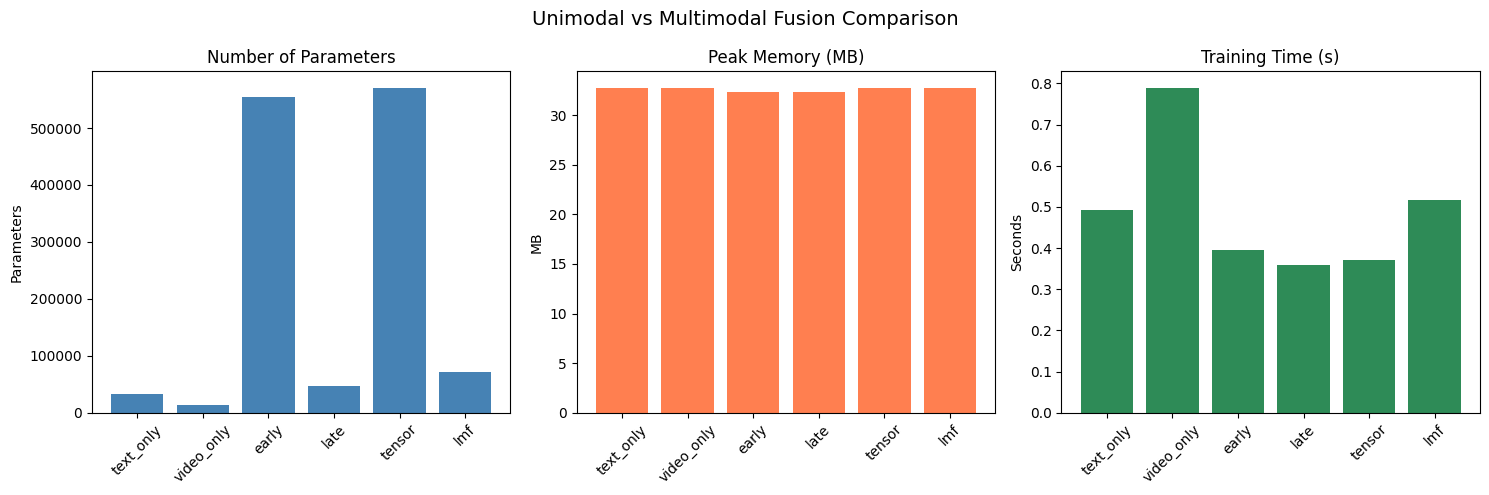

In [29]:
print(f"\n{'='*70}")
print(f"{'Method':<15} {'Val Acc':>10} {'Test Acc':>10} {'Params':>10} {'Time(s)':>10} {'Mem(MB)':>10}")
print(f"{'='*70}")
for name in ["text_only", "video_only", "early", "late", "tensor", "lmf"]:
    r = results[name]
    print(f"{name:<15} {r['best_val_acc']:>9.2f}% {r['test_acc']:>9.2f}% {r['params']:>10} {r['train_time']:>9.1f} {r['peak_mem_mb']:>9.1f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = ["text_only", "video_only", "early", "late", "tensor", "lmf"]

axes[0].bar(names, [results[n]["params"] for n in names], color="steelblue")
axes[0].set_title("Number of Parameters")
axes[0].set_ylabel("Parameters")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(names, [results[n]["peak_mem_mb"] for n in names], color="coral")
axes[1].set_title("Peak Memory (MB)")
axes[1].set_ylabel("MB")
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(names, [results[n]["train_time"] for n in names], color="seagreen")
axes[2].set_title("Training Time (s)")
axes[2].set_ylabel("Seconds")
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle("Unimodal vs Multimodal Fusion Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("fusion_comparison.png", dpi=150)
plt.show()

Generally speaking a unimodal model should be easier and cheaper to train, but have worse performance. However, in our case, the 2 largest multimodal models clearly overfit a lot on the training set, so we could argue that an advantage of unimodal models is that they are less likely to overfit.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [30]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-u6egdqh7
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-u6egdqh7
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=38e8634871110d0a40b89ee52173bed282dfa17d2e06612e8aed4fd85b400560
  Stored in directory: /tmp/pip-ephem-wheel-cache-jutsm05l/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [31]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 53.2MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [37]:
from google.colab import files
uploaded = files.upload()

Saving smiley.jpg to smiley.jpg


In [39]:
image_filename = "smiley.jpg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [40]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [41]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 65.14%
       a photo of a sad person: 25.90%
    a photo of an angry person: 8.95%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
    # TODO:
    # 1. Create Encoders for modalities
    # 2. Create a projector, which maps specific modality dimensions to a shared space.
    #     do this for each modality. (hint: fusions!)
    # 3. Create learnable temperature (this has already been done for you)

    # 1.

    super(CLModel, self).__init__()

    self.encoder_a = nn.Sequential(
            nn.Linear(dim_x1, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

    self.encoder_b = nn.Sequential(
            nn.Linear(dim_x2, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

    # 2.

    self.projector_a = nn.Linear(128, embedded_dim)
    self.projector_b = nn.Linear(128, embedded_dim)

    # 3.
    self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1/temp))

  def forward(self, x1, x2):
    # TODO:
    # 1. Extract the raw features
    # 2. Project them to the embedding space
    # 3. Normalize vectors and return

    h1 = self.encoder_a(x1)
    h2 = self.encoder_b(x2)

    z1 = self.projector_a(h1)
    z2 = self.projector_b(h2)

    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)

    return z1, z2

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  def __init__(self, model):
    # TODO: Initialize model and loss function as cross entropy loss
    super(ContrastiveLoss, self).__init__()
    self.model = model
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x1_emb, x2_emb,logit_scale):
    # TODO:
    # 1. Get the batch size (hint: you can get this
    #    from the dimensions of your embedded space)
    # 2. Create similarity matrix using einsum
    # 3. Create labels (hint: the coorect match for index i is label i)
    # 4. Compute Symmetric loss (loss amongst rows + loss amongst columns)/2

    batch_size = x1_emb.size(0)

    temp = logit_scale.exp()
    sim = torch.einsum('id,jd->ij', x1_emb, x2_emb) * temp

    labels = torch.arange(batch_size, device=x1_emb.device)

    loss = (self.loss_fn(sim, labels) + self.loss_fn(sim.T, labels)) / 2

    return loss





In [54]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b, model.logit_scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [55]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

In [56]:
class EgoBlindContrastiveDataset(Dataset):
    def __init__(self, text_feats, vid_feats):
        self.text = torch.tensor(text_feats, dtype=torch.float32)
        self.vid = torch.tensor(vid_feats, dtype=torch.float32)

    def __len__(self):
        return len(self.text)

    def __getitem__(self, idx):
        return self.text[idx], self.vid[idx]

contrastive_dataset = EgoBlindContrastiveDataset(X_text_train_f, X_vid_train_f)
contrastive_loader = DataLoader(contrastive_dataset, batch_size=64, shuffle=True, drop_last=True)
print(f"Contrastive dataset: {len(contrastive_dataset)} pairs")

Contrastive dataset: 191 pairs


In [57]:
device = "cuda" if torch.cuda.is_available() else "cpu"

cl_model = CLModel(dim_x1=TEXT_DIM, dim_x2=VID_DIM, embedded_dim=64, temp=0.07)
cl_loss = ContrastiveLoss(cl_model)

train_model(cl_model, cl_loss, contrastive_loader, num_epochs=10, learning_rate=3e-4, device=device)

Starting training for 10 epochs...
Epoch [1/10] | Loss: 4.3895
Epoch [2/10] | Loss: 4.1858
Epoch [3/10] | Loss: 4.1651
Epoch [4/10] | Loss: 4.1315
Epoch [5/10] | Loss: 4.0743
Epoch [6/10] | Loss: 4.0243
Epoch [7/10] | Loss: 3.9673
Epoch [8/10] | Loss: 3.9334
Epoch [9/10] | Loss: 3.8707
Epoch [10/10] | Loss: 3.8175


In [58]:
# Pick a few test samples and see if the model matches text to the right video
cl_model.eval()
num_candidates = 20

candidate_vids = torch.tensor(X_vid_test_f[:num_candidates], dtype=torch.float32)

for i in range(5):
    query_text = torch.tensor(X_text_test_f[i], dtype=torch.float32)

    query_feat = cl_model.encoder_a(query_text.unsqueeze(0).to(device))
    query_emb = F.normalize(cl_model.projector_a(query_feat), dim=1)

    cand_feat = cl_model.encoder_b(candidate_vids.to(device))
    cand_emb = F.normalize(cl_model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id,jd->ij', query_emb, cand_emb)
    best_idx = scores.argmax().item()

    print(f"\nQuery: '{test_df.iloc[test_idx[i]]['question']}'")
    print(f"  Matched to candidate {best_idx} (correct would be {i})")
    print(f"  Score for correct: {scores[0, i].item():.4f}, Score for match: {scores[0, best_idx].item():.4f}")


Query: 'Am I facing the gate now?'
  Matched to candidate 7 (correct would be 0)
  Score for correct: -0.1117, Score for match: -0.0990

Query: 'Is the staff or conductor near me?'
  Matched to candidate 9 (correct would be 1)
  Score for correct: -0.1278, Score for match: -0.0912

Query: 'What other services can I access from this station?'
  Matched to candidate 15 (correct would be 2)
  Score for correct: -0.1953, Score for match: -0.1290

Query: 'How do I use this water dispenser?'
  Matched to candidate 15 (correct would be 3)
  Score for correct: -0.1552, Score for match: -0.0921

Query: 'Is this the entrance to the disabled toilet?'
  Matched to candidate 15 (correct would be 4)
  Score for correct: -0.2146, Score for match: -0.1107


Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

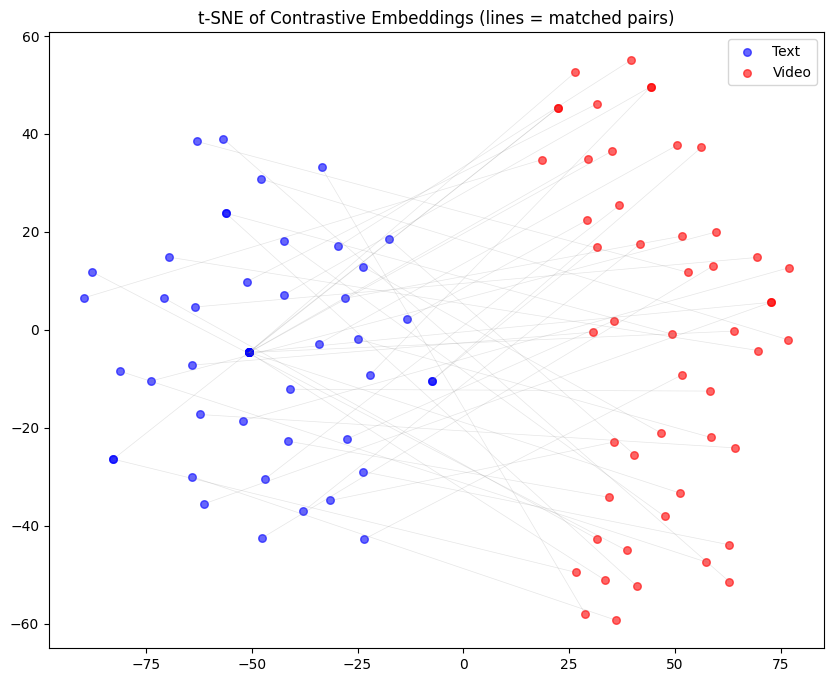

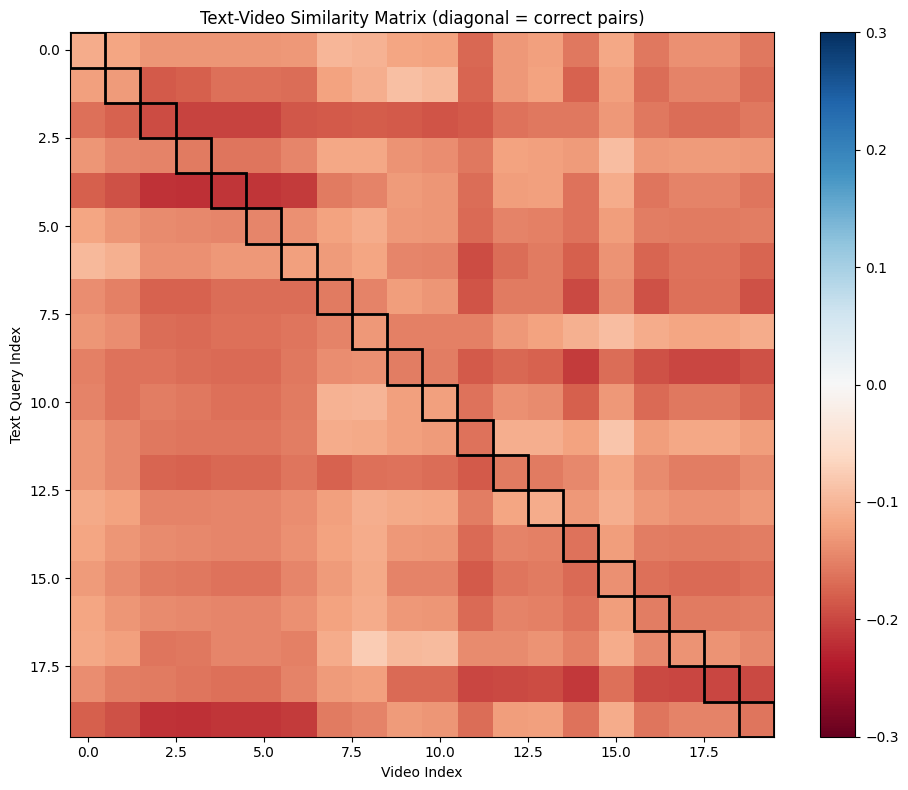

BEST ALIGNED PAIRS (highest diagonal similarity):
  Score: -0.1102 | Query: 'Which direction are the buildings in?'
  Score: -0.1117 | Query: 'Am I facing the gate now?'
  Score: -0.1223 | Query: 'Is there a clear path ahead for me to walk?'

WORST ALIGNED PAIRS (lowest diagonal similarity):
  Score: -0.2146 | Query: 'Is this the entrance to the disabled toilet?'
  Score: -0.1999 | Query: 'How can I reach coach No.3 from my position?'
  Score: -0.1953 | Query: 'What other services can I access from this station?'


In [60]:
# Visualize the aligned embedding space
cl_model.eval()
with torch.no_grad():
    text_t = torch.tensor(X_text_test_f[:50], dtype=torch.float32).to(device)
    vid_t = torch.tensor(X_vid_test_f[:50], dtype=torch.float32).to(device)

    text_emb = F.normalize(cl_model.projector_a(cl_model.encoder_a(text_t)), dim=1).cpu().numpy()
    vid_emb = F.normalize(cl_model.projector_b(cl_model.encoder_b(vid_t)), dim=1).cpu().numpy()

from sklearn.manifold import TSNE

all_emb = np.vstack([text_emb, vid_emb])
tsne = TSNE(n_components=2, perplexity=15, max_iter=500, random_state=42)
proj = tsne.fit_transform(all_emb)

text_proj = proj[:50]
vid_proj = proj[50:]

plt.figure(figsize=(10, 8))
plt.scatter(text_proj[:, 0], text_proj[:, 1], c='blue', label='Text', alpha=0.6, s=30)
plt.scatter(vid_proj[:, 0], vid_proj[:, 1], c='red', label='Video', alpha=0.6, s=30)

# Draw lines between matched pairs
for i in range(50):
    plt.plot([text_proj[i, 0], vid_proj[i, 0]],
             [text_proj[i, 1], vid_proj[i, 1]],
             'gray', alpha=0.2, linewidth=0.5)

plt.legend()
plt.title("t-SNE of Contrastive Embeddings (lines = matched pairs)")
plt.savefig("contrastive_alignment.png", dpi=150)
plt.show()

# Similarity heatmap for first 20 pairs
cl_model.eval()
with torch.no_grad():
    text_t = torch.tensor(X_text_test_f[:20], dtype=torch.float32).to(device)
    vid_t = torch.tensor(X_vid_test_f[:20], dtype=torch.float32).to(device)

    text_emb = F.normalize(cl_model.projector_a(cl_model.encoder_a(text_t)), dim=1)
    vid_emb = F.normalize(cl_model.projector_b(cl_model.encoder_b(vid_t)), dim=1)

    sim_matrix = torch.einsum('id,jd->ij', text_emb, vid_emb).cpu().numpy()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap='RdBu', vmin=-0.3, vmax=0.3)
ax.set_xlabel("Video Index")
ax.set_ylabel("Text Query Index")
ax.set_title("Text-Video Similarity Matrix (diagonal = correct pairs)")
plt.colorbar(im)

# Highlight diagonal
for i in range(20):
    ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor='black', linewidth=2))

plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150)
plt.show()

# Print best and worst aligned pairs
diag_scores = np.diag(sim_matrix)
best_pairs = np.argsort(diag_scores)[-3:][::-1]
worst_pairs = np.argsort(diag_scores)[:3]

print("BEST ALIGNED PAIRS (highest diagonal similarity):")
for idx in best_pairs:
    print(f"  Score: {diag_scores[idx]:.4f} | Query: '{test_df.iloc[test_idx[idx]]['question']}'")

print("\nWORST ALIGNED PAIRS (lowest diagonal similarity):")
for idx in worst_pairs:
    print(f"  Score: {diag_scores[idx]:.4f} | Query: '{test_df.iloc[test_idx[idx]]['question']}'")

1: The results were horrible, with negative scores for all correct pairs, but this isn't too surprising because for this homework I only used frame features instead of the actual frames themselves because the latency from google drive means that taking frames would be unrealistic (for the real project we will do everything on AWS so we can actually use both modalities to the fullest extent of their potential).

2: Contrastive learning is essentially a classification problem. Each sample in the batch produces a row of similarity scores against every other sample, and the correct match is exactly one index, making it equivalent to a classification task where the number of classes equals the batch size. Cross-entropy is used for many classification problems because it calculates loss based only on the probability assigned to the correct class, because it doesn't matter how much weight the model assigns to each incorrect answer specifically, only the amount it assigns to the correct class.

3: The t-SNE plot shows that text and video embeddings form two distinct clusters on opposite sides of the plot rather than being interleaved, confirming that the contrastive model largely failed to align the two modalities. The gray lines connecting matched pairs span nearly the entire width of the plot, meaning correct pairs are far apart in embedding space. Correct pairs are also rarely closest to each other.

The similarity heatmap reinforces this. The correct pairs on the diagonal are not consistently brighter than off-diagonal entries, meaning the model cannot reliably distinguish correct matches from incorrect ones. All scores are negative, indicating that even the best-aligned pairs are dissimilar.

The model performed best on simple spatial questions like "Which direction are the buildings in?" and "Am I facing the gate now?", which have answers that could be inferred from basic visual features like the distribution of large dark regions in the frame. The model performed worst on questions like "What other services can I access from this station?" and "How can I reach coach No.3?", which require reading text or understanding complex spatial layouts that frame features cannot capture.

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?

1: I think contrastive alignment is definitely the most interesting idea, because it is so cool that we can align two modalities by pushing matched pairs together and unmatched pairs apart. It is obvious in retrospect, yes, but also something that I would have never thought of on my own.

2: Contrastive alignment will be very important for our project for the reasons I mentioned earlier. We will want to align our modalities before fusion to ensure that there is less wastage of time and compute and attention during training.

Additionally, the comparison of fusion methods showed that late fusion generalizes well and is fastest, which means we can use it for the urgent query path, while reserving deeper fusion for non-urgent queries where latency is less important.